# PROJETO GRUPO 05

                    Exploratory Data Analysis Netflix Movies And Series

# BIBLIOTECAS

In [14]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import statistics
import pandas as pd
import pandas_profiling
import plotly.graph_objects as go

C:\Users\paulo\AppData\Local\Temp\ipykernel_15436\2349818001.py:7: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


# CARREGANDO A BASE DE DADOS

In [15]:
df = pd.read_csv('./netflix.csv')

In [16]:
# função do Pandas em Python que é usada para remover linhas duplicadas de um DataFrame.
df.drop_duplicates()

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,NaN,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,NaN,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55
...,...,...,...,...,...,...,...,...,...,...
7095,2022-03-11,6,5,1,Worst Roommate Ever,TV Show,Yes,"Mar 1, 2022",10,81
7096,2022-03-11,7,7,2,Vikings: Valhalla,TV Show,Yes,"Feb 25, 2022",14,100
7097,2022-03-11,8,8,-,Shooter,Movie,NaN,"Aug 1, 2014",3,7
7098,2022-03-11,9,9,7,Shrek 2,Movie,NaN,"Mar 1, 2022",10,33


In [17]:
#mostrar os 5 primeiros elementos do dataset
df.head()

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,NaN,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,NaN,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55


# Análise Exploratória de Dados (EDA)

In [18]:
#checa o numero de linhas e colunas do conjunto de dados
df.shape

(7100, 10)

In [19]:
#checa o tipo de dados presentes nas colunas do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   As of                 7100 non-null   object
 1   Rank                  7100 non-null   int64 
 2   Year to Date Rank     7100 non-null   object
 3   Last Week Rank        7100 non-null   object
 4   Title                 7100 non-null   object
 5   Type                  7100 non-null   object
 6   Netflix Exclusive     4599 non-null   object
 7   Netflix Release Date  7100 non-null   object
 8   Days In Top 10        7100 non-null   int64 
 9   Viewership Score      7100 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 554.8+ KB


In [20]:
# quantos valores nulos estão presentes
df.isnull().sum()

As of                      0
Rank                       0
Year to Date Rank          0
Last Week Rank             0
Title                      0
Type                       0
Netflix Exclusive       2501
Netflix Release Date       0
Days In Top 10             0
Viewership Score           0
dtype: int64

### Substituindo todos os valores em Year_to_Date_Rank,Last_Week_Rank por zeros e substituindo os valores nulos em Netflix_Exclusive como No.

In [21]:
df['Year to Date Rank']=df['Year to Date Rank'].replace('-',0)
df['Last Week Rank']=df['Last Week Rank'].replace('-',0)
df['Netflix Exclusive']=df['Netflix Exclusive'].fillna('NO')

In [22]:
# Novamente verificando quaisquer valores nulos presentes
df.isnull().sum()

As of                   0
Rank                    0
Year to Date Rank       0
Last Week Rank          0
Title                   0
Type                    0
Netflix Exclusive       0
Netflix Release Date    0
Days In Top 10          0
Viewership Score        0
dtype: int64

## Convertendo o tipo de dados para as colunas a seguir.

In [23]:
df['Year to Date Rank']=df['Year to Date Rank'].astype('int64')
df['Last Week Rank']=df['Last Week Rank'].astype('int64')
df['Netflix Release Date']=pd.to_datetime(df['Netflix Release Date'])
df['As of']=pd.to_datetime(df['As of'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   As of                 7100 non-null   datetime64[ns]
 1   Rank                  7100 non-null   int64         
 2   Year to Date Rank     7100 non-null   int64         
 3   Last Week Rank        7100 non-null   int64         
 4   Title                 7100 non-null   object        
 5   Type                  7100 non-null   object        
 6   Netflix Exclusive     7100 non-null   object        
 7   Netflix Release Date  7100 non-null   datetime64[ns]
 8   Days In Top 10        7100 non-null   int64         
 9   Viewership Score      7100 non-null   int64         
dtypes: datetime64[ns](2), int64(5), object(3)
memory usage: 554.8+ KB


In [26]:
# #descrevendo as colunas
df.describe()

,As of,Rank,Year to Date Rank,Last Week Rank,Netflix Release Date,Days In Top 10,Viewership Score
count,7100,7100.000000,7100.000000,7100.000000,7100,7100.000000,7100.000000
mean,2021-03-21 12:00:00.000000256,5.500000,4.439296,1.737324,2020-06-21 08:05:32.619718144,24.123662,122.790141
min,2020-04-01 00:00:00,1.000000,0.000000,0.000000,2007-01-15 00:00:00,1.000000,1.000000
25%,2020-09-25 00:00:00,3.000000,2.000000,0.000000,2020-04-26 00:00:00,3.000000,19.000000
50%,2021-03-21 12:00:00,5.500000,4.000000,0.000000,2020-10-02 00:00:00,7.000000,50.000000
75%,2021-09-15 00:00:00,8.000000,7.000000,3.000000,2021-05-14 00:00:00,18.000000,128.000000
max,2022-03-11 00:00:00,10.000000,10.000000,10.000000,2022-03-04 00:00:00,428.000000,1474.000000
std,NaN,2.872484,3.041267,2.620020,NaN,58.473789,213.861642


### Usando o pandas_profiling para conhecer os dados.

In [27]:
profiling = pandas_profiling.ProfileReport(df)
profiling.to_file("profiling.html")
profiling

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\paulo\anaconda3\lib\site-packages\visions\backends\pandas\series_utils.py:60: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return fn(series, *args, **kwargs)
C:\Users\paulo\anaconda3\lib\site-packages\multimethod\__init__.py:315: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return func(*args, **kwargs)
C:\Users\paulo\anaconda3\lib\site-packages\visions\backends\pandas\series_utils.py:60: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return fn(series, *args, **kwargs)
C:\Users\paulo\anaconda3\lib\site-packages\multimethod\__init__.py:315: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return func(*args, 

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# No pandas_profiling na seção de correlações, podemos ver que há uma correlação entre Days_In_Top_10 e Viewership_Score

In [32]:
# CALCULANDO A CORRELAÇÃO ENTRE 'DAYS IN TOP 10' E 'Viewership Score'
dd=np.corrcoef(df['Viewership Score'],df['Days In Top 10'])
dd[1, 0]

0.9624135870948405

# PLOTAGEM DO CALCULO ACIMA

C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


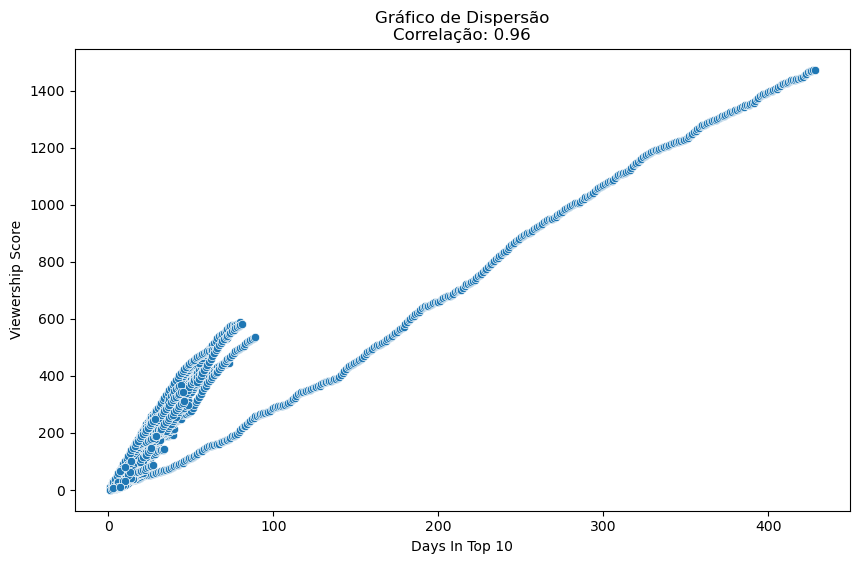

In [34]:
# Suponha que seu DataFrame seja chamado 'df'
# Calcula a correlação entre as colunas 'Days In Top 10' e 'Viewership Score'
correlation = df['Days In Top 10'].corr(df['Viewership Score'])

# Cria o gráfico de dispersão com a linha de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Days In Top 10', y='Viewership Score')
plt.title(f"Gráfico de Dispersão\nCorrelação: {correlation:.2f}")
plt.xlabel('Days In Top 10')
plt.ylabel('Viewership Score')
plt.show()


<AxesSubplot:xlabel='Days In Top 10', ylabel='Viewership Score'>

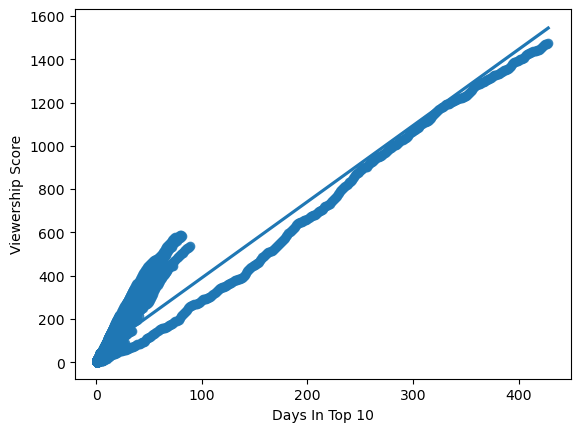

In [35]:
sns.regplot(data=df, x=df['Days In Top 10'], y=df['Viewership Score'])

### Usando o countplot para ver qual gênero teve melhor desempenho.

C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<AxesSubplot:xlabel='Type', ylabel='count'>

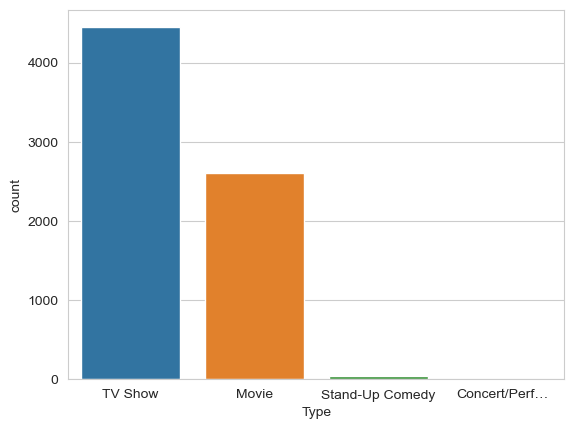

In [38]:
sns.set_style('whitegrid')
sns.countplot(data=df,x=df['Type'])

# Programas de TV dominam os dias no top 10

In [39]:
#Conhecer os 10 melhores programas de TV agrupando-os.
tv_shows=df[df['Type']=='TV Show']
tv_shows_top=tv_shows.groupby('Title')['Days In Top 10'].max().sort_values(ascending=False)[0:11]
tv_shows_top

Title
Cocomelon               428
Ozark                    89
Cobra Kai                81
Manifest                 80
The Queenâs Gambit     73
Outer Banks              72
Squid Game               66
All American             66
Bridgerton               58
Lucifer                  57
Virgin River             55
Name: Days In Top 10, dtype: int64

# PLOTAGEM DOS DADOS ACIMA

C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\paulo\anaconda3\lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\paulo\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\paulo\anaconda3\lib\site-packages\IPython\core\pylabtools.

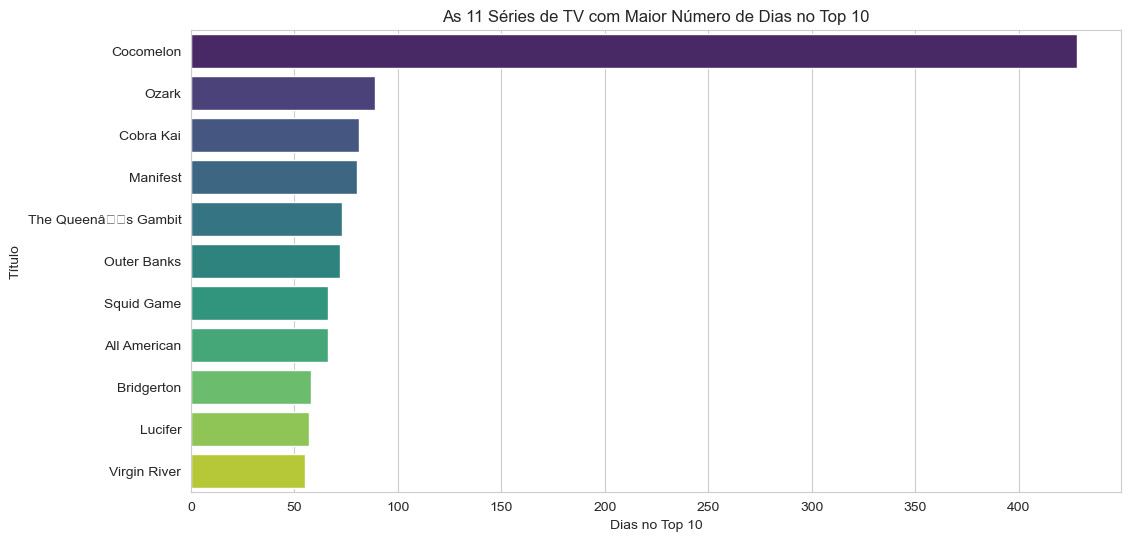

In [41]:
# Selecione as séries de TV (Type == 'TV Show') do DataFrame original
tv_shows = df[df['Type'] == 'TV Show']

# Agrupe as séries de TV por título e pegue o máximo de "Days In Top 10" para cada título
tv_shows_top = tv_shows.groupby('Title')['Days In Top 10'].max().sort_values(ascending=False).head(11)

# Crie um gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=tv_shows_top.values, y=tv_shows_top.index, palette='viridis')
plt.title('As 11 Séries de TV com Maior Número de Dias no Top 10')
plt.xlabel('Dias no Top 10')
plt.ylabel('Título')
plt.show()

#### O gráfico de barras apresenta as 11 séries de TV mais populares na Netflix com base no número de dias em que estiveram no Top 10. "Cocomelon" se destaca como a série com o maior número de dias no Top 10, indicando sua grande popularidade. Há uma variedade de títulos populares representados, mostrando que diferentes séries atraíram a atenção dos espectadores. Algumas séries conseguiram manter uma presença consistente no Top 10, enquanto outras tiveram picos de popularidade temporários. Em resumo, o gráfico fornece insights sobre as séries de TV mais populares na plataforma.

 ### Analisando os 50 principais programas se os programas Netflix_Exclusive têm melhor desempenho do que os programas não Netflix_Exclusive

In [50]:
tv=tv_shows.groupby('Title').max()
tv=tv.sort_values(by='Days In Top 10',ascending=False)[:51]
tv_report = tv.groupby('Netflix Exclusive').count()

In [51]:
labels = ['NÃO EXCLUSIVOS','EXCLUSIVOS']
values= tv_report['Days In Top 10']
fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent',
                             insidetextorientation='radial'
                            )])
fig.show()

### O Netflix Exclusive tem melhor desempenho nos 50 principais programas de TV.

In [53]:
# Analisando os 10 principais programas se os programas Netflix_Exclusive têm melhor desempenho 
# do que os programas não Netflix_Exclusive
xx=tv_shows.groupby('Title').max()
xx=xx.sort_values(by='Days In Top 10',ascending=False)
xx=xx[:11]
tv_report = xx.groupby('Netflix Exclusive').count()

In [54]:
labels = ['NÃO EXCLUSIVOS','EXCLUSIVOS']
values= tv_report['Days In Top 10']
fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent',
                             insidetextorientation='radial'
                            )])
fig.show()

### Netflix Exclusive tem melhor desempenho nos 10 principais programas de TV.

In [56]:
# Conhecer os 10 melhores programas de TV agrupando-os.
movies=df[df['Type']=='Movie']
movies_top=movies.groupby(df['Title'])['Days In Top 10'].max().sort_values(ascending=False)
movies_top[0:11]

Title
The Mitchells vs. The Machines    31
How the Grinch Stole Christmas    29
Vivo                              29
365 Days                          28
Despicable Me 2                   27
Donât Look Up                   26
The Christmas Chronicles 2        24
Illumination Presents The G…      24
We Can Be Heroes                  24
Red Notice                        23
The Unforgivable                  22
Name: Days In Top 10, dtype: int64

In [57]:
# Analisando os 50 melhores filmes se os programas Netflix_Exclusive 
# têm melhor desempenho do que os programas não Netflix_Exclusive
mov=movies.groupby(df['Title']).max()
mov=mov.sort_values(by='Days In Top 10',ascending=False)
mov=mov[:51]
movie_report = mov.groupby(['Netflix Exclusive']).count()

In [59]:
labels = ['NÃO EXCLUSIVOS','EXCLUSIVOS']
values= movie_report['Days In Top 10']
fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent',
                             insidetextorientation='radial'
                            )])
fig.show()

### O Netflix Exclusive tem melhor desempenho nos 50 melhores filmes.

C:\Users\paulo\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 128 (\x80) missing from current font.

C:\Users\paulo\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 153 (\x99) missing from current font.



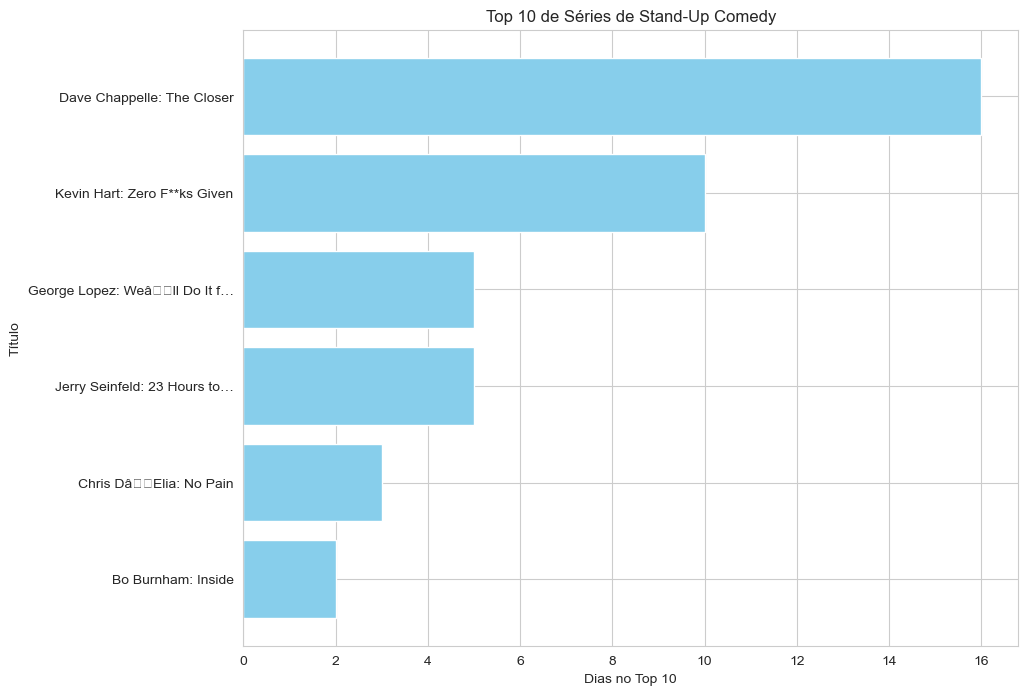

In [61]:
# Conhecer os 10 melhores programas de TV agrupando-os.
stand_up=df[df['Type']=='Stand-Up Comedy']
stand_up_top=stand_up.groupby(df['Title'])['Days In Top 10'].max().sort_values(ascending=False)
stand_up_top=pd.DataFrame(stand_up_top)
stand_up_top
plt.figure(figsize=(10, 8))
plt.barh(stand_up_top.index, stand_up_top['Days In Top 10'], color='skyblue')
plt.xlabel('Dias no Top 10')
plt.ylabel('Título')
plt.title('Top 10 de Séries de Stand-Up Comedy')

# Inverter a ordem das barras para que a barra superior corresponda ao título com o maior número de dias no Top 10
plt.gca().invert_yaxis()

# Exibe o gráfico
plt.show()

#### O gráfico de barras horizontais representa os 10 melhores programas de Stand-Up Comedy na Netflix, com base no número de dias em que cada programa esteve no Top 10. Ele mostra a variedade de títulos populares nesse gênero, destacando o programa mais popular com a barra mais alta. A presença desses programas no Top 10 sugere um interesse contínuo do público por Stand-Up Comedy na plataforma. O gráfico oferece uma visão rápida das preferências dos espectadores em relação a esse tipo de conteúdo. 


#### Analisando a comédia stand-up se os programas Netflix_Exclusive têm melhor desempenho do que os programas não Netflix_Exclusive

In [62]:
zz=stand_up.groupby(df['Title']).max()
zz=zz.sort_values(by='Days In Top 10',ascending=False)
stand_up_report = zz.groupby(['Netflix Exclusive']).count()
stand_up_report['percentage'] = (stand_up_report['Days In Top 10']/stand_up_report['Days In Top 10'].sum())*100
stand_up_report[['Days In Top 10','percentage']]

,Days In Top 10,percentage
Netflix Exclusive,,
Yes,6,100.0


- Não existe Stand-Up Comedy que não seja exclusivo da Netflix

# Conclusão
## Há uma alta correlação entre Viewership_Score e Days_In_Top_10
## Netflix Exclusive tem melhor desempenho na categoria de programas de TV
## Netflix Exclusive tem melhor desempenho na categoria de filmes
## Não há programas de comédia stand-up exclusivos da Netflix.